#✅ Step-by-Step GAN Practical with CIFAR-10

🧾 Step 1: Import Required Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, Reshape, Flatten, Conv2D, Conv2DTranspose, LeakyReLU, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt


#🧾 Step 2: Load and Preprocess CIFAR-10 Dataset

In [2]:
# Load dataset and normalize images between -1 and 1 for GAN
(x_train, _), (_, _) = tf.keras.datasets.cifar10.load_data()
x_train = (x_train.astype("float32") - 127.5) / 127.5  # Normalize to [-1, 1]

# Reduce the dataset for faster training
x_train = x_train[:10000]

# Shuffle and batch the dataset
BUFFER_SIZE = x_train.shape[0]
BATCH_SIZE = 64
train_dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)


#🧾 Step 3: Build Generator Model

In [3]:
def build_generator():
    model = Sequential([
        Dense(8*8*256, use_bias=False, input_shape=(100,)),
        LeakyReLU(),
        Reshape((8, 8, 256)),  # Reshape to 3D

        Conv2DTranspose(128, kernel_size=5, strides=1, padding='same', use_bias=False),
        LeakyReLU(),

        Conv2DTranspose(64, kernel_size=5, strides=2, padding='same', use_bias=False),
        LeakyReLU(),

        Conv2DTranspose(3, kernel_size=5, strides=2, padding='same', use_bias=False, activation='tanh')
    ])
    return model


#🧾 Step 4: Build Discriminator Model

In [4]:
def build_discriminator():
    model = Sequential([
        Conv2D(64, kernel_size=5, strides=2, padding='same', input_shape=[32, 32, 3]),
        LeakyReLU(),
        Dropout(0.3),

        Conv2D(128, kernel_size=5, strides=2, padding='same'),
        LeakyReLU(),
        Dropout(0.3),

        Flatten(),
        Dense(1)
    ])
    return model


#🧾 Step 5: Define Loss Functions and Optimizers

In [5]:
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

generator = build_generator()
discriminator = build_discriminator()

generator_optimizer = Adam(1e-4)
discriminator_optimizer = Adam(1e-4)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#🧾 Step 6: Define Training Step Function

In [6]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])  # Random noise

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)

        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)

        # Loss for generator and discriminator
        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        disc_loss = cross_entropy(tf.ones_like(real_output), real_output) + \
                    cross_entropy(tf.zeros_like(fake_output), fake_output)

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

    return gen_loss, disc_loss


#🧾 Step 7: Generate and Display Fake Images

In [7]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i] + 1) / 2)  # De-normalize
        plt.axis('off')
    plt.suptitle(f"Epoch {epoch}")
    plt.tight_layout()
    plt.show()


#🧾 Step 8: Train the GAN

Epoch 1, Gen Loss: 2.2021, Disc Loss: 0.2916


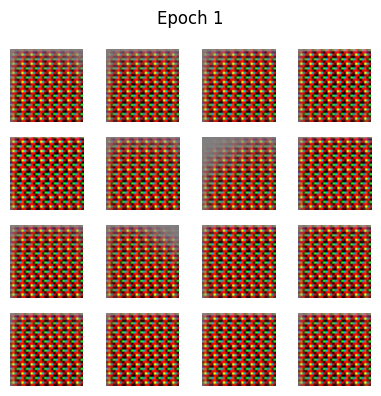

Epoch 2, Gen Loss: 4.6046, Disc Loss: 0.2914


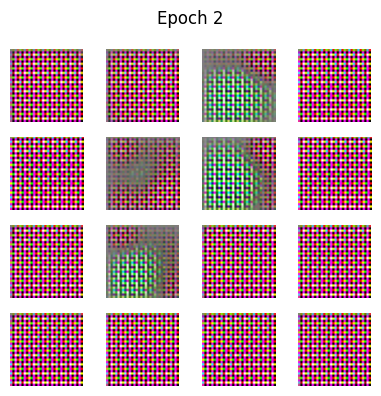

Epoch 3, Gen Loss: 7.2390, Disc Loss: 0.1509


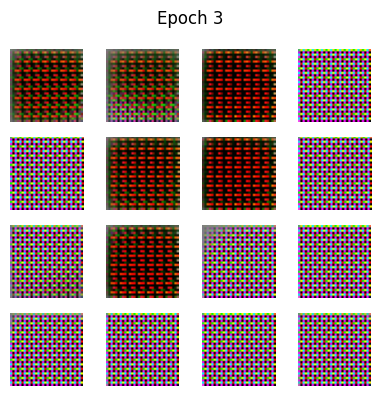

Epoch 4, Gen Loss: 1.8885, Disc Loss: 0.7236


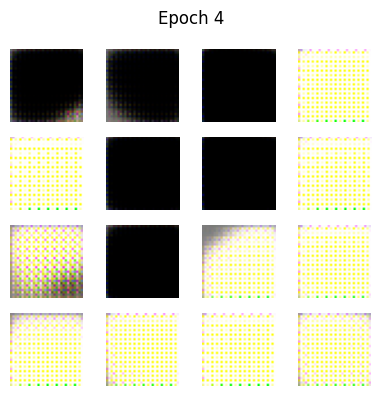

Epoch 5, Gen Loss: 5.0388, Disc Loss: 0.0898


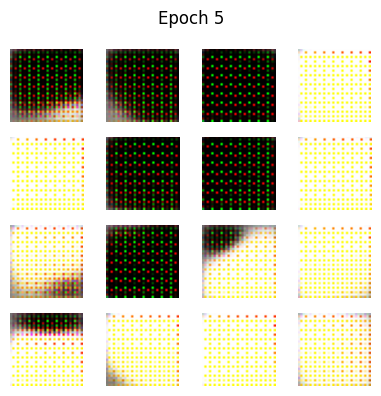

In [8]:
def train(dataset, epochs):
    seed = tf.random.normal([16, 100])
    for epoch in range(epochs):
        for image_batch in dataset:
            gen_loss, disc_loss = train_step(image_batch)
        print(f"Epoch {epoch+1}, Gen Loss: {gen_loss:.4f}, Disc Loss: {disc_loss:.4f}")
        generate_and_save_images(generator, epoch + 1, seed)

# Train for 5 epochs (can increase later)
train(train_dataset, epochs=5)
